<a href="https://colab.research.google.com/github/ZaidAl2004/AER850_Project3/blob/main/AER850_Project3_Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 147.5±130.9 MB/s, size: 645.0 KB)
val: Scanning /content/drive/MyDrive/project3data/project3data/data/data/valid/labels.cache... 105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 159.9Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 26, len(boxes) = 19108. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.3s/it 23.0s
                   all        105      19108   

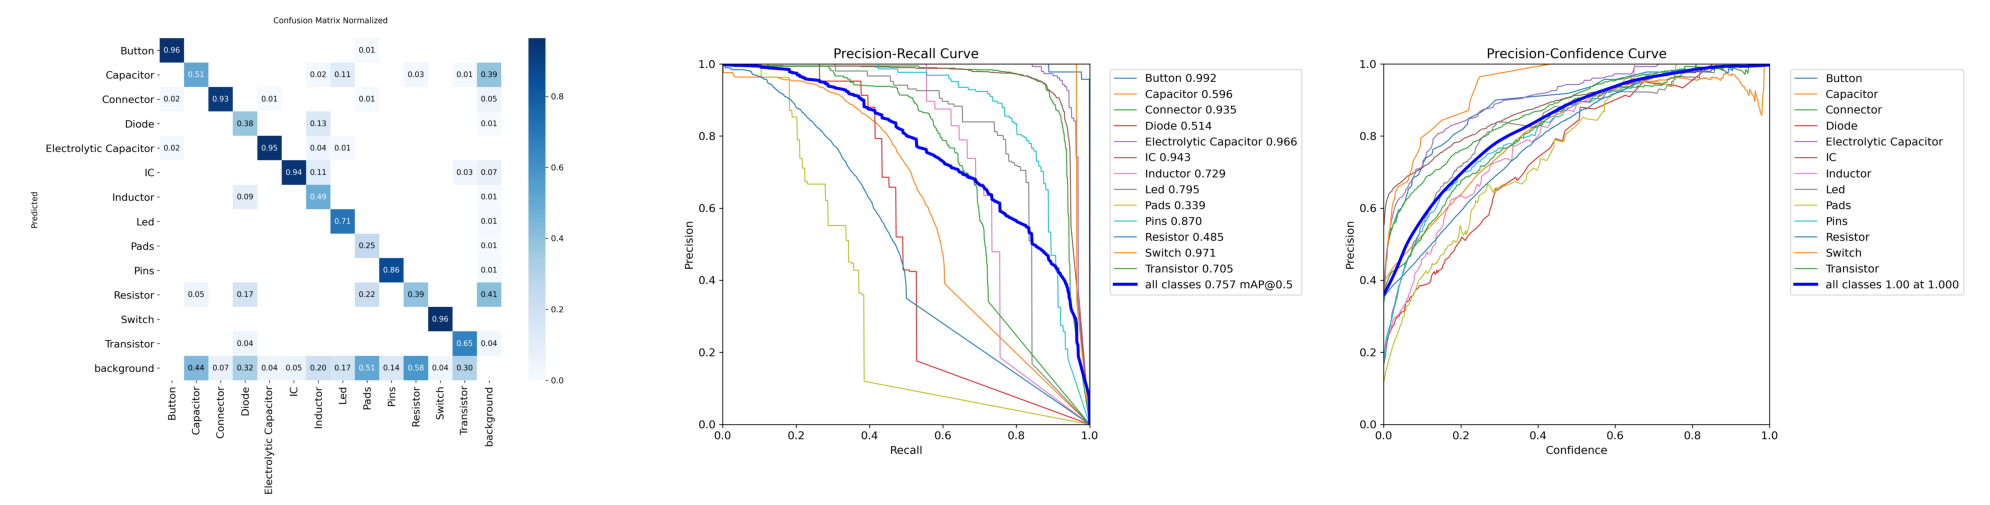

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

#Load image
from google.colab import drive
drive.mount('/content/drive')

#!pip install ultralytics
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best.pt")

project_dir = 'runs/detect'
run_name = 'pcb_detector_v11_val'

metrics = model.val(
    plots=True,
    project=project_dir,
    name=run_name
)  #Runs validation and saves the results for metric analysis

results_path = os.path.join(project_dir, run_name)

files_to_show = [
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png"
]

# List all files
files = os.listdir(results_path)

    # Sort them alphabetically so they are easier to read
files.sort()

for file_name in files:
    print(f"- {file_name}")


plt.figure(figsize=(20, 6))

for i, file_name in enumerate(files_to_show):
    plt.subplot(1, 3, i + 1)

    full_file_path = os.path.join(results_path, file_name)

    if os.path.exists(full_file_path):
        img = mpimg.imread(full_file_path)
        plt.imshow(img)
        plt.axis('off') # Remove axis ticks
    else:
        plt.text(0.5, 0.5, f"Missing:\n{file_name}",
                 ha='center', va='center', color='red')
        plt.axis('off')

plt.tight_layout()
plt.show()
